# Housing Market Segmentation using Agglomerative Clustering
## Problem Statement
Segment housing data into meaningful groups using unsupervised learning techniques.

In [17]:
#importing required libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram,linkage
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
#loading dataset
df=pd.read_csv('USA_Housing.csv')
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [19]:
df.isnull().sum()

,0
Avg. Area Income,0
Avg. Area House Age,0
Avg. Area Number of Rooms,0
Avg. Area Number of Bedrooms,0
Area Population,0
Price,0
Address,0


In [20]:
X=df.drop(columns=['Address','Price'])

In [21]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

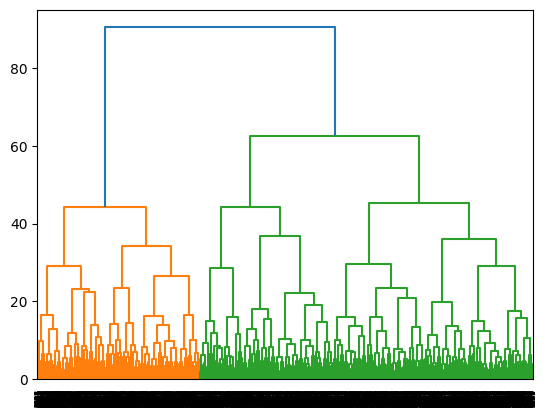

In [22]:
dendrogram(linkage(X_scaled, method = 'ward'))
plt.show()

In [23]:
hc=AgglomerativeClustering(n_clusters=5)

In [24]:
y_hc = hc.fit_predict(X_scaled)
df['Cluster']=y_hc

In [25]:
plt.figure(figsize=(8,5))

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

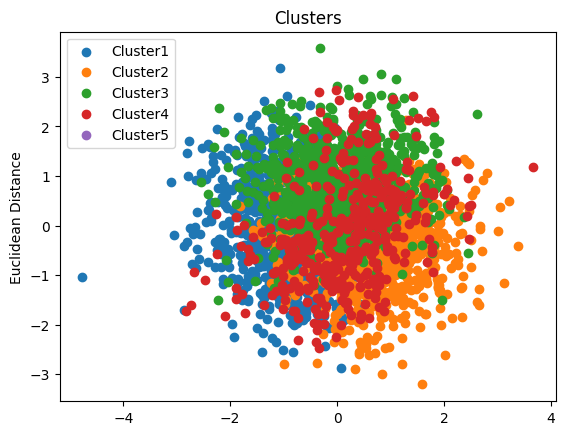

In [26]:
for i in range(1,6):
  plt.scatter(X_scaled[y_hc==i,0],X_scaled[y_hc==i,1],label=f'Cluster{i}')
plt.title('Clusters')
plt.ylabel('Euclidean Distance')
plt.legend()
plt.show()


(5000, 2)


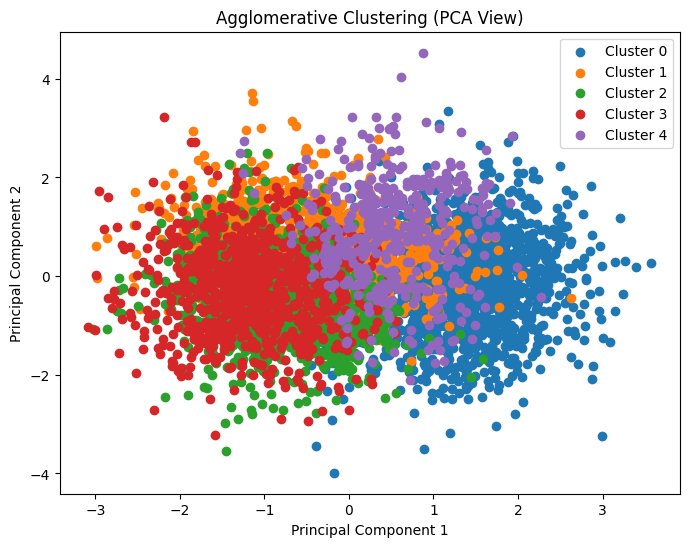

In [27]:
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
X_pca=pca.fit_transform(X_scaled)
print(X_pca.shape)
plt.figure(figsize=(8,6))

for i in range(5):

    plt.scatter(
        X_pca[y_hc == i, 0],
        X_pca[y_hc == i, 1],
        label=f'Cluster {i}'
    )

plt.title('Agglomerative Clustering (PCA View)')

plt.xlabel('Principal Component 1')

plt.ylabel('Principal Component 2')

plt.legend()

plt.show()

In [28]:
from sklearn.metrics import silhouette_score
score=silhouette_score(X_scaled,y_hc)
print('Silhouette Score=',score)

Silhouette Score= 0.08288542178287486


<Axes: >

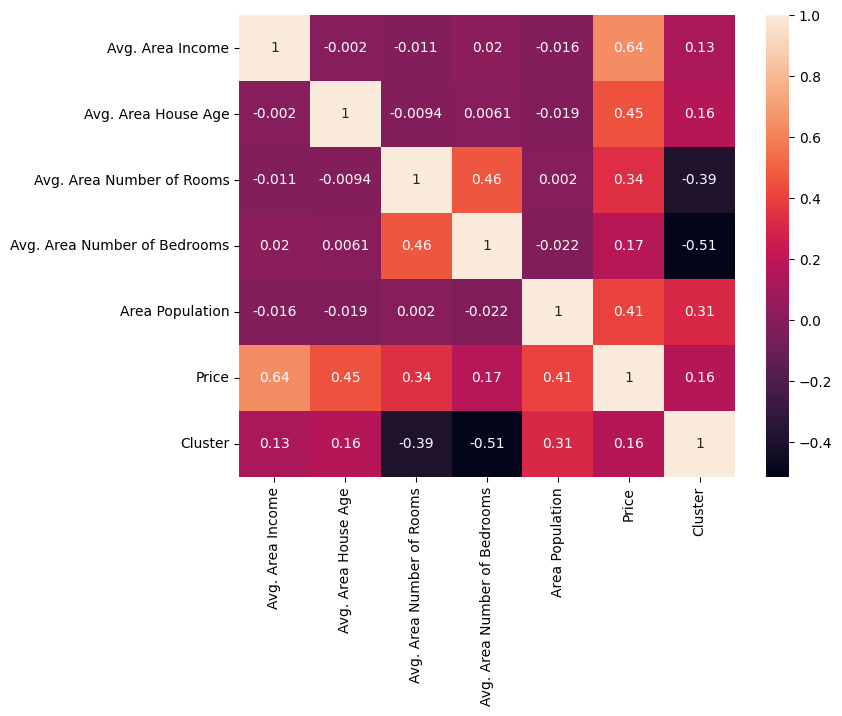

In [29]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True)

In [30]:
cluster_summary=df.groupby('Cluster').mean(numeric_only=True)
cluster_summary

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
Cluster,,,,,,
0,69206.741568,5.873801,7.808220,5.150359,33107.366979,1.279879e+06
1,57988.723112,5.831278,6.806024,3.520265,38530.457702,9.921365e+05
2,75430.586085,5.688652,6.343497,3.357543,31740.527566,1.187559e+06
3,68923.312452,6.694960,6.085054,3.098020,39024.961050,1.291678e+06
4,70280.078053,5.884088,7.806307,3.970922,47926.059757,1.538589e+06
